# Experiment 9 - Generative Adversarial Networks
**Dataset:** Fashion-MNIST | **Models:** Vanilla GAN, DCGAN

In [4]:
!pip install wandb huggingface_hub -q

In [5]:
import wandb
wandb.login()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: ERROR Invalid API key: API key must have 40+ characters, has 37.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ashishk200088 (ashishk200088-delhi-technological-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [6]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os
from torch.utils.data import DataLoader
from huggingface_hub import HfApi, create_repo

# change to your huggingface username
HF_REPO = "your-hf-username/exp9-gans"

WANDB_PROJECT = "exp9-gans"
EPOCHS        = 10
BATCH_SIZE    = 128
LATENT_DIM    = 100
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LOSS_FNS   = ["bce", "lsgan", "wgan"]
OPTIMIZERS = ["adam", "sgd", "rmsprop"]
MODELS     = ["vanilla", "dcgan"]

print(DEVICE)

cpu


### Dataset

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 306kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.60MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.81MB/s]


train: 60000  test: 10000


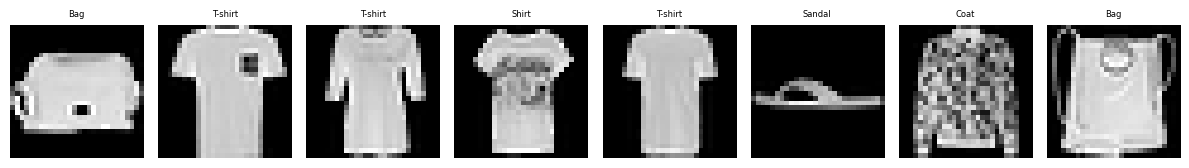

In [8]:
# normalize to [-1, 1] for GAN training
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_data = torchvision.datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'train: {len(train_data)}  test: {len(test_data)}')

imgs, labels = next(iter(train_loader))
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    axes[i].imshow(imgs[i].squeeze(), cmap='gray')
    axes[i].set_title(class_names[labels[i]], fontsize=6)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Vanilla GAN - Generator and Discriminator

In [9]:
class VanillaGenerator(nn.Module):
    def __init__(self, latent_dim):
        super(VanillaGenerator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


class VanillaDiscriminator(nn.Module):
    def __init__(self):
        super(VanillaDiscriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.net(x)

### DCGAN - Generator and Discriminator

In [10]:
class DCGenerator(nn.Module):
    def __init__(self, latent_dim):
        super(DCGenerator, self).__init__()
        self.net = nn.Sequential(
            # latent -> 7x7x256
            nn.ConvTranspose2d(latent_dim, 256, 7, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # 7x7 -> 14x14
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # 14x14 -> 28x28
            nn.ConvTranspose2d(128, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        z = z.view(z.size(0), z.size(1), 1, 1)
        return self.net(z)


class DCDiscriminator(nn.Module):
    def __init__(self):
        super(DCDiscriminator, self).__init__()
        self.net = nn.Sequential(
            # 28x28 -> 14x14
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 14x14 -> 7x7
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # 7x7 -> 1x1
            nn.Conv2d(128, 1, 7, 1, 0, bias=False)
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

### Loss Functions - BCE, LSGAN, WGAN

In [11]:
bce = nn.BCEWithLogitsLoss()
mse = nn.MSELoss()

def disc_loss(real_out, fake_out, loss_type):
    if loss_type == 'bce':
        real_loss = bce(real_out, torch.ones_like(real_out))
        fake_loss = bce(fake_out, torch.zeros_like(fake_out))
        return (real_loss + fake_loss) / 2
    elif loss_type == 'lsgan':
        real_loss = mse(real_out, torch.ones_like(real_out))
        fake_loss = mse(fake_out, torch.zeros_like(fake_out))
        return (real_loss + fake_loss) / 2
    elif loss_type == 'wgan':
        return -(real_out.mean() - fake_out.mean())

def gen_loss(fake_out, loss_type):
    if loss_type == 'bce':
        return bce(fake_out, torch.ones_like(fake_out))
    elif loss_type == 'lsgan':
        return mse(fake_out, torch.ones_like(fake_out))
    elif loss_type == 'wgan':
        return -fake_out.mean()

### Optimizer Factory

In [12]:
def get_optimizer(model, name):
    if name == 'adam':
        # betas tuned for GAN stability
        return optim.Adam(model.parameters(), lr=2e-4, betas=(0.5, 0.999))
    elif name == 'sgd':
        return optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
    else:
        return optim.RMSprop(model.parameters(), lr=5e-5)

### Training Loop

In [13]:
def train_epoch(G, D, loader, opt_g, opt_d, loss_type):
    G.train(); D.train()
    g_running = 0
    d_running = 0

    for real, _ in loader:
        real = real.to(DEVICE)
        bs   = real.size(0)

        # train discriminator
        z         = torch.randn(bs, LATENT_DIM).to(DEVICE)
        fake      = G(z).detach()
        real_out  = D(real)
        fake_out  = D(fake)
        d_loss    = disc_loss(real_out, fake_out, loss_type)
        opt_d.zero_grad()
        d_loss.backward()
        opt_d.step()

        # weight clipping for wgan
        if loss_type == 'wgan':
            for p in D.parameters():
                p.data.clamp_(-0.01, 0.01)

        # train generator
        z        = torch.randn(bs, LATENT_DIM).to(DEVICE)
        fake     = G(z)
        fake_out = D(fake)
        g_loss   = gen_loss(fake_out, loss_type)
        opt_g.zero_grad()
        g_loss.backward()
        opt_g.step()

        g_running += g_loss.item()
        d_running += d_loss.item()

    n = len(loader)
    return g_running / n, d_running / n

### Visualization

In [14]:
def show_generated(G, epoch, tag, n=16):
    G.eval()
    with torch.no_grad():
        z    = torch.randn(n, LATENT_DIM).to(DEVICE)
        imgs = G(z).cpu()
    imgs = (imgs + 1) / 2  # [-1,1] -> [0,1]
    fig, axes = plt.subplots(2, 8, figsize=(12, 3))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(imgs[i].squeeze(), cmap='gray')
        ax.axis('off')
    plt.suptitle(f'epoch {epoch} - {tag}', fontsize=9)
    plt.tight_layout()
    plt.show()
    return fig

### Main Experiment Runner

In [15]:
results       = {}
saved_generators = {}

def run_experiment(arch, loss_type, opt_name):
    name = f'{arch}_{loss_type}_{opt_name}'
    print(f'\nstarting: {name}')

    wandb.init(project=WANDB_PROJECT, name=name, config={
        'arch': arch, 'loss': loss_type, 'optimizer': opt_name, 'epochs': EPOCHS
    })

    if arch == 'vanilla':
        G = VanillaGenerator(LATENT_DIM).to(DEVICE)
        D = VanillaDiscriminator().to(DEVICE)
    else:
        G = DCGenerator(LATENT_DIM).to(DEVICE)
        D = DCDiscriminator().to(DEVICE)

    opt_g = get_optimizer(G, opt_name)
    opt_d = get_optimizer(D, opt_name)

    g_losses = []
    d_losses = []

    for epoch in range(1, EPOCHS + 1):
        g_loss, d_loss = train_epoch(G, D, train_loader, opt_g, opt_d, loss_type)
        g_losses.append(g_loss)
        d_losses.append(d_loss)
        wandb.log({'epoch': epoch, 'g_loss': g_loss, 'd_loss': d_loss})
        print(f'  epoch {epoch}/{EPOCHS}  g_loss={g_loss:.4f}  d_loss={d_loss:.4f}')

        if epoch % 5 == 0 or epoch == EPOCHS:
            fig = show_generated(G, epoch, name)
            wandb.log({f'generated_ep{epoch}': wandb.Image(fig)})
            plt.close(fig)

    # loss curves
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(g_losses, label='generator')
    ax.plot(d_losses, label='discriminator')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.set_title(name)
    ax.legend()
    plt.tight_layout()
    plt.show()
    wandb.log({'loss_curve': wandb.Image(fig)})
    plt.close(fig)

    torch.save(G.state_dict(), f'{name}_G.pt')
    torch.save(D.state_dict(), f'{name}_D.pt')
    saved_generators[name] = G
    results[name] = {'g_loss': g_losses[-1], 'd_loss': d_losses[-1]}

    wandb.finish()
    return G, D

### Quick Test - run this first


starting: vanilla_bce_adam


  epoch 1/10  g_loss=1.1680  d_loss=0.4797
  epoch 2/10  g_loss=1.9279  d_loss=0.4226
  epoch 3/10  g_loss=1.9587  d_loss=0.4514
  epoch 4/10  g_loss=1.8202  d_loss=0.4651
  epoch 5/10  g_loss=1.5324  d_loss=0.5136


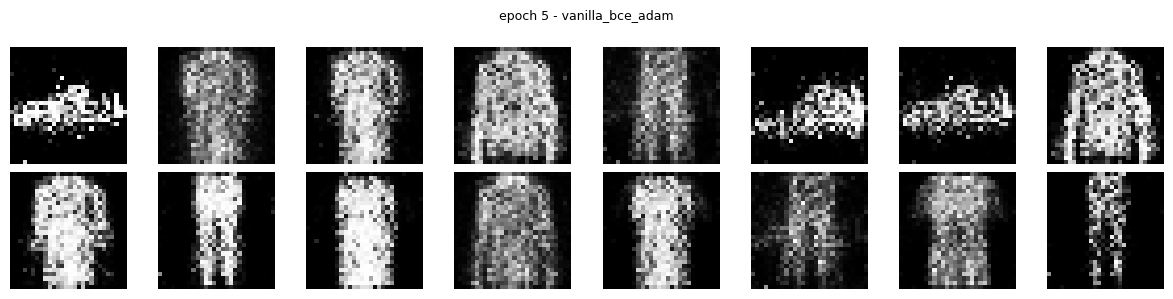

  epoch 6/10  g_loss=1.3411  d_loss=0.5638
  epoch 7/10  g_loss=1.2181  d_loss=0.5768
  epoch 8/10  g_loss=1.2015  d_loss=0.5804
  epoch 9/10  g_loss=1.1571  d_loss=0.5941
  epoch 10/10  g_loss=1.1169  d_loss=0.6031


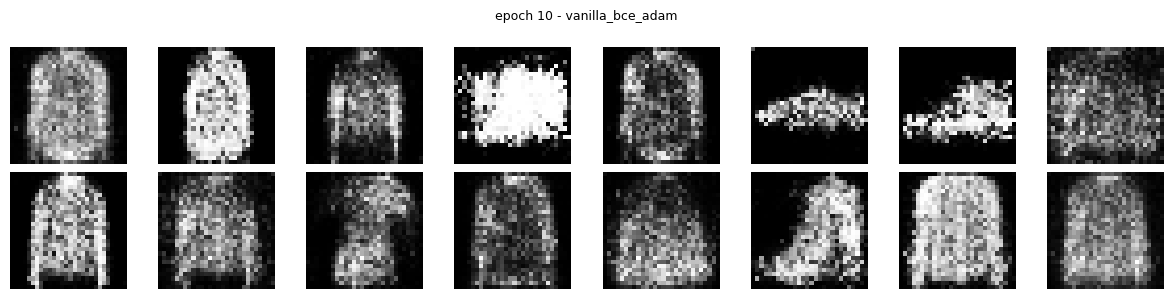

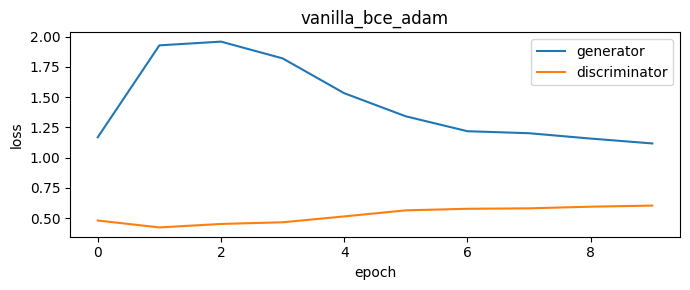

d_loss,▃▁▂▃▅▆▇▇██
epoch,▁▂▃▃▄▅▆▆▇█
g_loss,▁██▇▄▃▂▂▁▁
d_loss,0.60308
epoch,10
g_loss,1.11694



starting: dcgan_bce_adam


  epoch 1/10  g_loss=1.5346  d_loss=0.3787
  epoch 2/10  g_loss=1.3319  d_loss=0.4252
  epoch 3/10  g_loss=1.2917  d_loss=0.4675
  epoch 4/10  g_loss=1.2904  d_loss=0.4736
  epoch 5/10  g_loss=1.1953  d_loss=0.4923


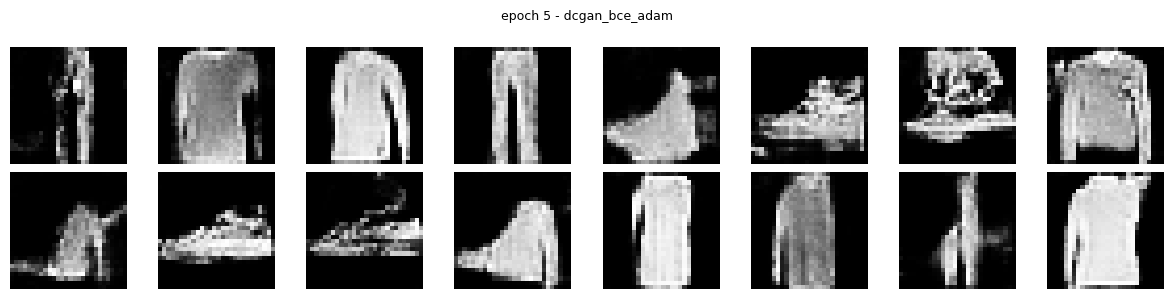

  epoch 6/10  g_loss=1.2070  d_loss=0.4900
  epoch 7/10  g_loss=1.3415  d_loss=0.4618
  epoch 8/10  g_loss=1.3870  d_loss=0.4574
  epoch 9/10  g_loss=1.2649  d_loss=0.4787
  epoch 10/10  g_loss=1.2923  d_loss=0.4744


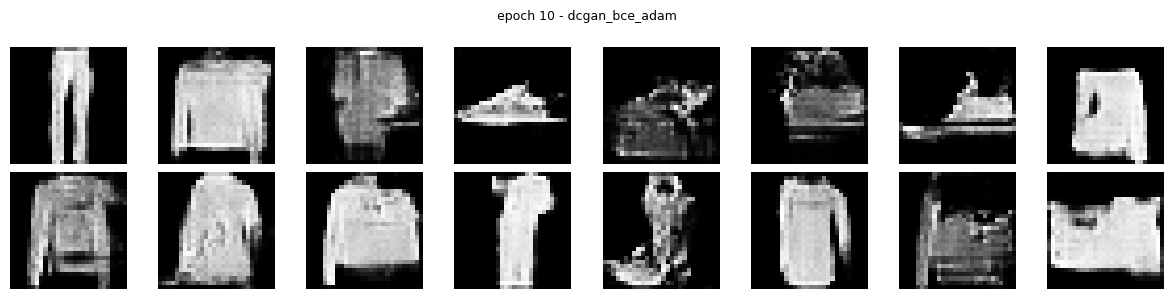

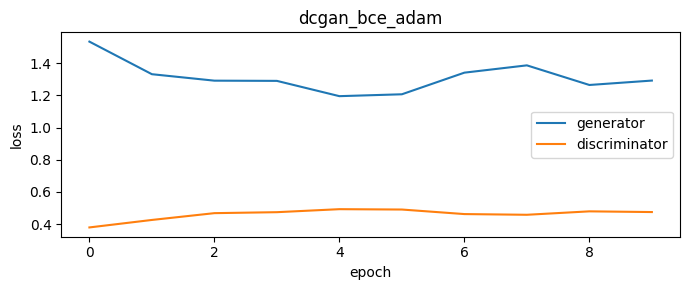

d_loss,▁▄▆▇██▆▆▇▇
epoch,▁▂▃▃▄▅▆▆▇█
g_loss,█▄▃▃▁▁▄▅▂▃
d_loss,0.47435
epoch,10
g_loss,1.29229


(DCGenerator(
   (net): Sequential(
     (0): ConvTranspose2d(100, 256, kernel_size=(7, 7), stride=(1, 1), bias=False)
     (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (2): ReLU(inplace=True)
     (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (5): ReLU(inplace=True)
     (6): ConvTranspose2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (7): Tanh()
   )
 ),
 DCDiscriminator(
   (net): Sequential(
     (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (1): LeakyReLU(negative_slope=0.2, inplace=True)
     (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (4): LeakyReLU(negative_slope=0.2, inplace=True)
    

In [16]:
run_experiment('vanilla', 'bce', 'adam')
run_experiment('dcgan',   'bce', 'adam')

### Full Grid - all combinations


starting: vanilla_bce_adam


  epoch 1/10  g_loss=1.2172  d_loss=0.4730
  epoch 2/10  g_loss=1.7679  d_loss=0.5017
  epoch 3/10  g_loss=1.7129  d_loss=0.4906
  epoch 4/10  g_loss=1.4024  d_loss=0.5405
  epoch 5/10  g_loss=1.3174  d_loss=0.5691


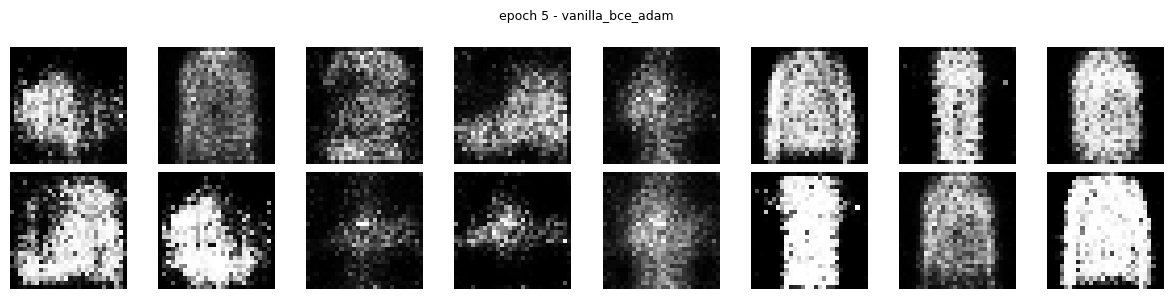

  epoch 6/10  g_loss=1.2600  d_loss=0.5681
  epoch 7/10  g_loss=1.1909  d_loss=0.5854
  epoch 8/10  g_loss=1.1310  d_loss=0.6079
  epoch 9/10  g_loss=1.1097  d_loss=0.6117
  epoch 10/10  g_loss=1.1061  d_loss=0.6071


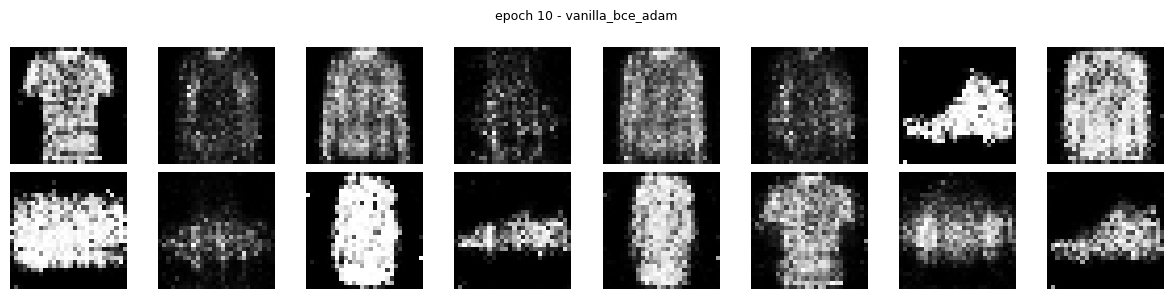

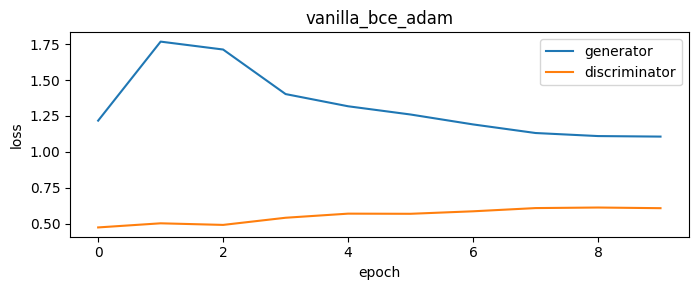

d_loss,▁▂▂▄▆▆▇███
epoch,▁▂▃▃▄▅▆▆▇█
g_loss,▂█▇▄▃▃▂▁▁▁
d_loss,0.60715
epoch,10
g_loss,1.10608



starting: vanilla_bce_sgd


  epoch 1/10  g_loss=0.7953  d_loss=0.3745
  epoch 2/10  g_loss=1.5401  d_loss=0.3007
  epoch 3/10  g_loss=2.4069  d_loss=0.1751
  epoch 4/10  g_loss=2.8068  d_loss=0.1400
  epoch 5/10  g_loss=3.2343  d_loss=0.1213


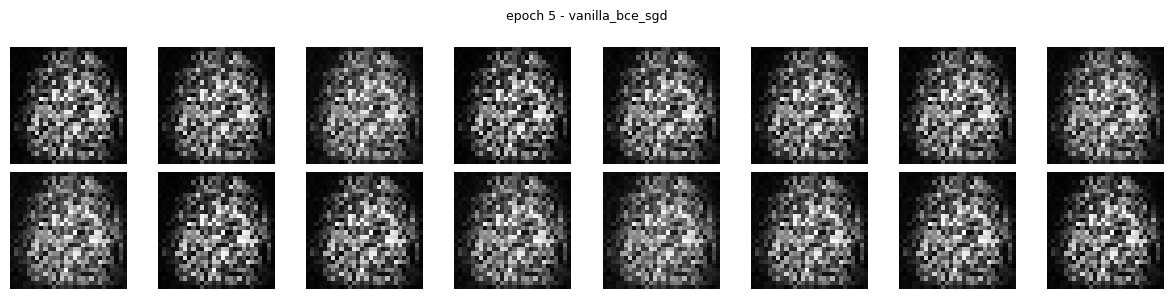

  epoch 6/10  g_loss=3.6071  d_loss=0.1848
  epoch 7/10  g_loss=3.8538  d_loss=0.1877
  epoch 8/10  g_loss=3.4112  d_loss=0.2469
  epoch 9/10  g_loss=3.4205  d_loss=0.1542
  epoch 10/10  g_loss=3.5833  d_loss=0.1460


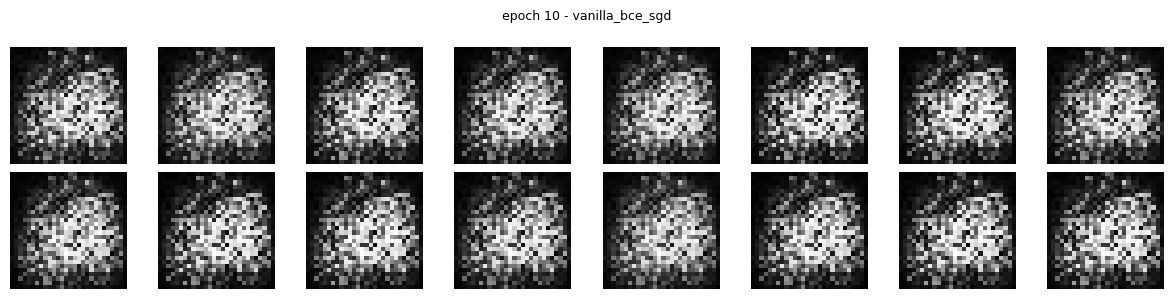

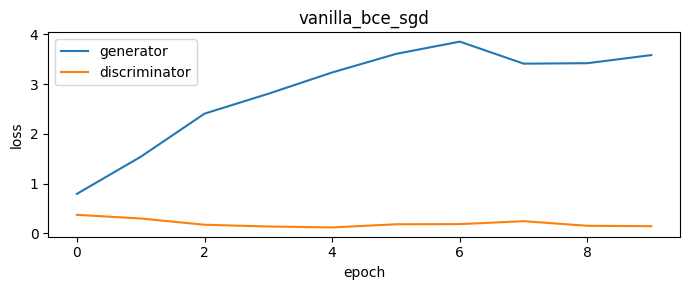

d_loss,█▆▂▂▁▃▃▄▂▂
epoch,▁▂▃▃▄▅▆▆▇█
g_loss,▁▃▅▆▇▇█▇▇▇
d_loss,0.146
epoch,10
g_loss,3.58326



starting: vanilla_bce_rmsprop


  epoch 1/10  g_loss=0.8652  d_loss=0.4644
  epoch 2/10  g_loss=1.4051  d_loss=0.3598
  epoch 3/10  g_loss=2.0289  d_loss=0.2867
  epoch 4/10  g_loss=2.5839  d_loss=0.2415
  epoch 5/10  g_loss=2.7659  d_loss=0.2576


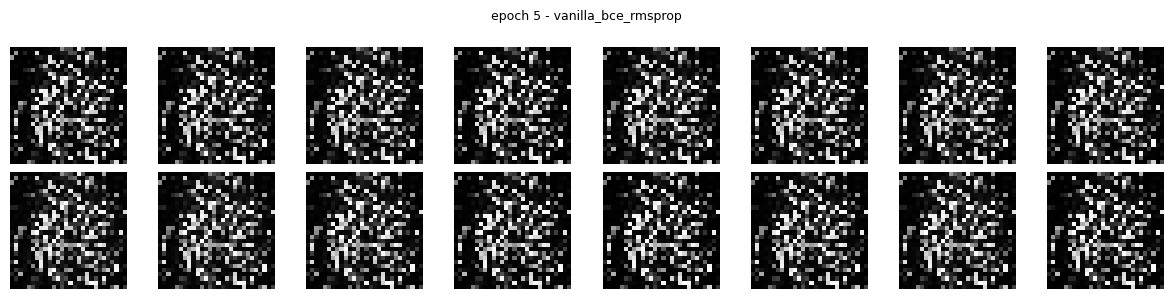

  epoch 6/10  g_loss=2.7660  d_loss=0.2586
  epoch 7/10  g_loss=2.9671  d_loss=0.2429
  epoch 8/10  g_loss=2.9204  d_loss=0.2593
  epoch 9/10  g_loss=3.1131  d_loss=0.2292
  epoch 10/10  g_loss=3.2690  d_loss=0.2354


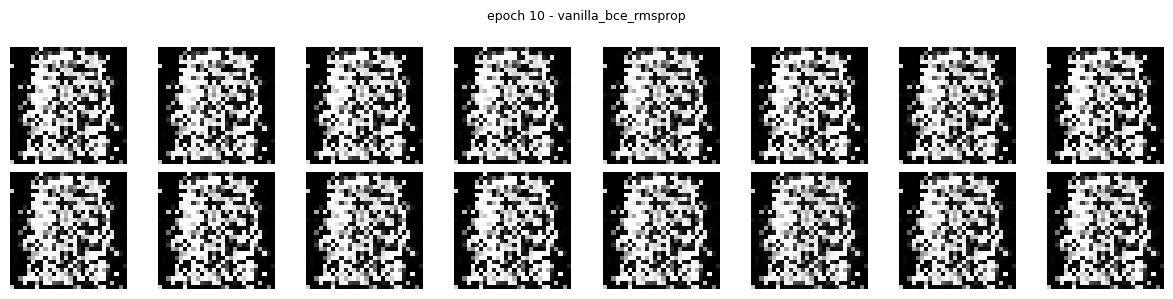

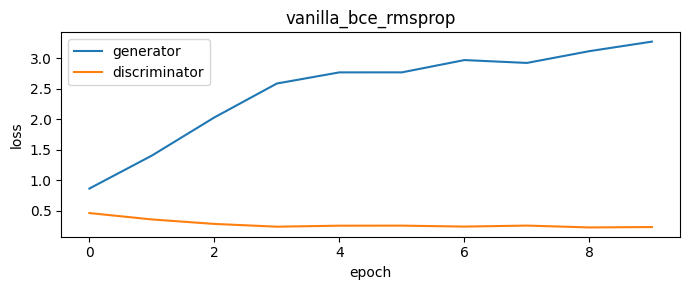

d_loss,█▅▃▁▂▂▁▂▁▁
epoch,▁▂▃▃▄▅▆▆▇█
g_loss,▁▃▄▆▇▇▇▇██
d_loss,0.23539
epoch,10
g_loss,3.269



starting: vanilla_lsgan_adam


  epoch 1/10  g_loss=1.0463  d_loss=0.0675
  epoch 2/10  g_loss=0.7897  d_loss=0.1228
  epoch 3/10  g_loss=0.6573  d_loss=0.1534
  epoch 4/10  g_loss=0.6136  d_loss=0.1563
  epoch 5/10  g_loss=0.5774  d_loss=0.1647


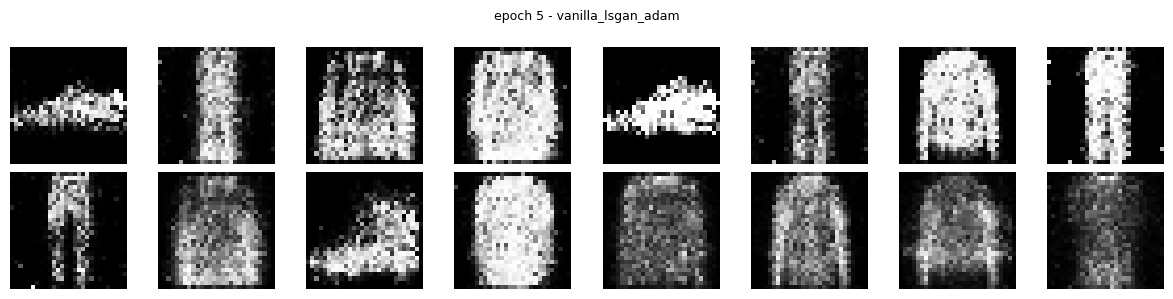

  epoch 6/10  g_loss=0.5365  d_loss=0.1790
  epoch 7/10  g_loss=0.5012  d_loss=0.1870
  epoch 8/10  g_loss=0.4918  d_loss=0.1892
  epoch 9/10  g_loss=0.4642  d_loss=0.1957
  epoch 10/10  g_loss=0.4415  d_loss=0.2010


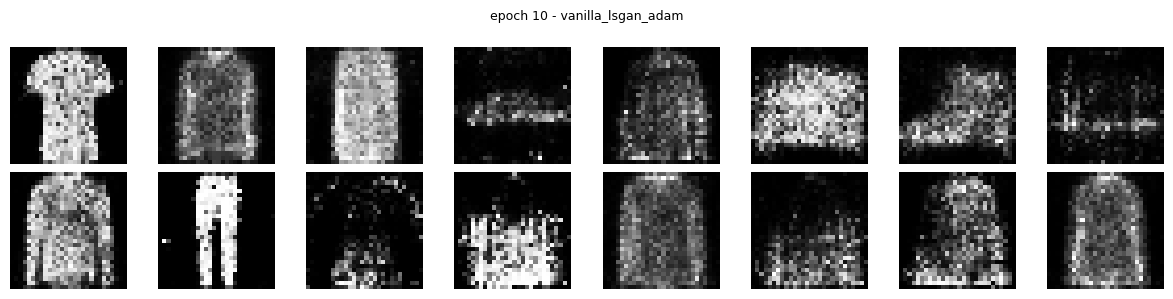

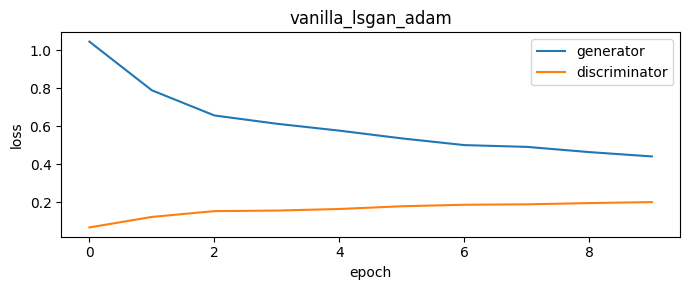

d_loss,▁▄▆▆▆▇▇▇██
epoch,▁▂▃▃▄▅▆▆▇█
g_loss,█▅▃▃▃▂▂▂▁▁
d_loss,0.20099
epoch,10
g_loss,0.4415



starting: vanilla_lsgan_sgd


  epoch 1/10  g_loss=0.7122  d_loss=0.0401
  epoch 2/10  g_loss=0.9861  d_loss=0.0328
  epoch 3/10  g_loss=0.9962  d_loss=0.0197
  epoch 4/10  g_loss=0.9829  d_loss=0.0260
  epoch 5/10  g_loss=0.9564  d_loss=0.0261


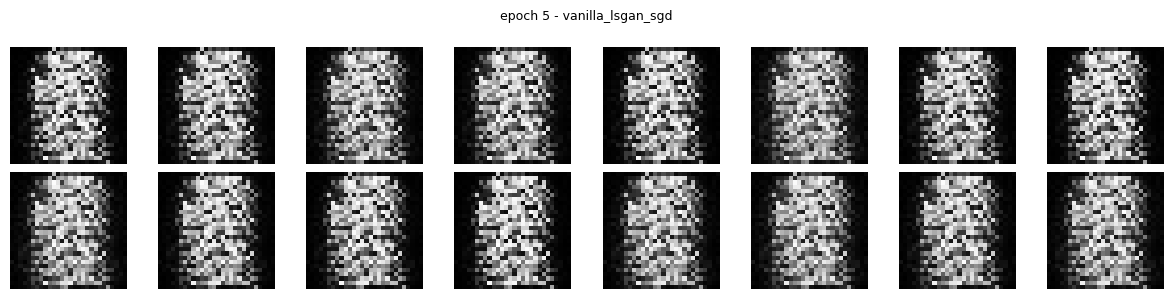

In [ ]:
for arch in MODELS:
    for lf in LOSS_FNS:
        for opt in OPTIMIZERS:
            run_experiment(arch, lf, opt)

### Results Summary

In [ ]:
print(f'{"config":<35} {"g_loss":>10} {"d_loss":>10}')
print('-' * 57)
for k, v in sorted(results.items(), key=lambda x: x[1]['g_loss']):
    print(f'{k:<35} {v["g_loss"]:>10.4f} {v["d_loss"]:>10.4f}')

### Upload to HuggingFace

In [ ]:
create_repo(HF_REPO, exist_ok=True)
api = HfApi()

for name in saved_generators.keys():
    for suffix in ['_G.pt', '_D.pt']:
        fname = f'{name}{suffix}'
        if os.path.exists(fname):
            api.upload_file(
                path_or_fileobj=fname,
                path_in_repo=f'models/{fname}',
                repo_id=HF_REPO
            )
            print(f'uploaded: {fname}')

print(f'https://huggingface.co/{HF_REPO}')

In [ ]:
username = wandb.api.viewer()['entity']
print(f'W&B : https://wandb.ai/{username}/{WANDB_PROJECT}')
print(f'HF  : https://huggingface.co/{HF_REPO}')